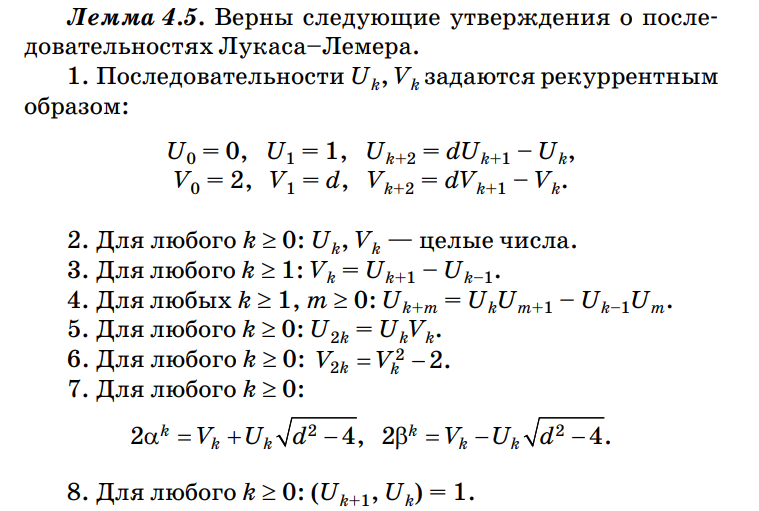

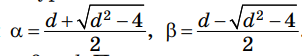

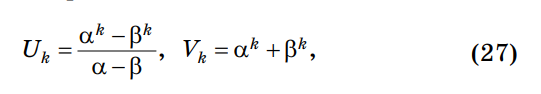

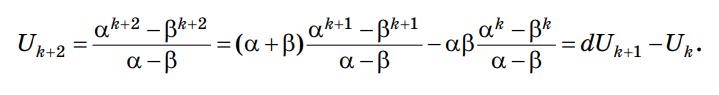


In [14]:
import pandas as pd
from math import sqrt, pow, gcd

class LucasLehmerLemma():
    def __init__(self, d) -> None:
        self.d = d
        self.U_seq = [0, 1]
        self.V_seq = [2, d]
        self.df = pd.DataFrame(
            columns=[
                "U",
                "V",
                "Property 1",
                "Property 3",
                "Property 4",
                "Property 5",
                "Property 6",
                "Property 7",
                "Property 8",
            ]
        )
        self.df.index.name = "k"

    def generate(self):
        for k in range(2, 50):
            # Find next elements by ops with previous two k
            U_k = self.U_seq[-2]
            U_k1 = self.U_seq[-1]
            U_k2 = self.d * U_k1 - U_k
            self.U_seq.append(U_k2)

            V_k = self.V_seq[-2]
            V_k1 = self.V_seq[-1]
            V_k2 = self.d * V_k1 - V_k
            self.V_seq.append(V_k2)

        self.df["U"] = self.U_seq
        self.df["V"] = self.V_seq

        # Check properties
        self.df["Property 1"] = self.df.apply(
            lambda row: self._verify_property_1(row["U"], row["V"], row.name),
            axis=1
        )
        self.df["Property 3"] = [
            self._verify_property_3(k) for k in range(len(self.V_seq))
        ]
        self.df["Property 3"] = [
            self._verify_property_3(k) for k in range(len(self.V_seq))
        ]
        self.df["Property 4"] = [
            self._verify_property_4(k, m=3) for k in range(len(self.df))
        ]
        self.df["Property 5"] = [
            self._verify_property_5(k) for k in range(len(self.df))
        ]
        self.df["Property 6"] = [
            self._verify_property_6(k) for k in range(len(self.df))
        ]
        self.df["Property 7"] = [
            self._verify_property_7(k) for k in range(len(self.df))
        ]
        self.df["Property 8"] = [
            self._verify_property_8(k) for k in range(len(self.df))
        ]

        return self.df

    def _verify_property_1(self, U_k_theory, V_k_theory, k):
        """ alpha + beta = d; alpha * beta = 1 """

        root = sqrt(self.d * self.d - 4)
        alpha = (self.d + root) / 2
        beta = (self.d - root) / 2

        U_k = round((pow(alpha, (k)) - pow(beta, (k))) / (alpha - beta))
        V_k = round((pow(alpha, (k)) + pow(beta, (k))))

        is_the_same =( U_k == U_k_theory and V_k == V_k_theory) if k < 36 else "Float limit exceeded"
        return [U_k, V_k, is_the_same]

    def _verify_property_3(self, k):
        """Для любого k >= 1: Vk = Uk_+1 - Uk_-1"""
        if 0 < k < len(self.U_seq) - 1:
            # V_k = U_{k+1} - U_{k-1}
            v_calc = self.U_seq[k+1] - self.U_seq[k-1]
            return [v_calc, self.V_seq[k] == v_calc]

        return "Pass"

    def _verify_property_4(self, k, m):
        """U_{k+m} = U_k * U_{m+1} - U_{k-1} * U_m"""
        if 1 <= k < len(self.U_seq) - m:
            u_km_theory = self.U_seq[k + m]
            u_km_calc = (
                self.U_seq[k] * self.U_seq[m + 1] - self.U_seq[k - 1] * self.U_seq[m]
            )
            return [u_km_calc, u_km_theory == u_km_calc]
        return "Pass"

    def _verify_property_5(self, k):
        """U_{2k} = U_k * V_k"""
        if 2 * k < len(self.U_seq):
            u_2k_theory = self.U_seq[2 * k]
            u_2k_calc = self.U_seq[k] * self.V_seq[k]
            return [u_2k_calc, u_2k_theory == u_2k_calc]
        return "Index out of range"

    def _verify_property_6(self, k):
        """V_{2k} = V_k^2 - 2"""
        if 2 * k < len(self.V_seq):
            v_2k_theory = self.V_seq[2 * k]
            v_2k_calc = self.V_seq[k] ** 2 - 2
            return [v_2k_calc, v_2k_theory == v_2k_calc]
        return "Index out of range"


    def _verify_property_7(self, k):
        """V_k + U_k * sqrt(D) = 2alpha^k; V_k - U_k * sqrt(D) = 2*beta^k"""

        if k >= len(self.U_seq) or k > 20: 
            return f"Skip (k={k} > 30 due to precision limits)"
    
        if k >= len(self.U_seq):
            return "Index out of range"
        
        D_sqrt = sqrt(self.d * self.d - 4)
        alpha = (self.d + D_sqrt) / 2
        beta = (self.d - D_sqrt) / 2
        
        left_plus = self.V_seq[k] + self.U_seq[k] * D_sqrt
        left_minus = self.V_seq[k] - self.U_seq[k] * D_sqrt
    
        right_alpha = 2 * (alpha ** k)
        right_beta = 2 * (beta ** k)
        

        epsilon = 1e-6
        is_valid_plus = abs(left_plus - right_alpha) < epsilon
        is_valid_minus = abs(left_minus - right_beta) < epsilon
        
        return [left_plus, left_minus, is_valid_plus and is_valid_minus]


    def _verify_property_8(self, k):
        """НОД(U_{k+1}, U_k) == 1"""
        if k < len(self.U_seq) - 1:
            u_curr = self.U_seq[k]
            u_next = self.U_seq[k+1]

            current_gcd = gcd(u_next, u_curr)

            return [current_gcd, current_gcd == 1]
        return "Pass"


lll = LucasLehmerLemma(d=3)
df = lll.generate()
display(df)

,U,V,Property 1,Property 3,Property 4,Property 5,Property 6,Property 7,Property 8
k,,,,,,,,,
0,0,2,"[0, 2, True]",Pass,Pass,"[0, True]","[2, True]","[2.0, 2.0, True]","[1, True]"
1,1,3,"[1, 3, True]","[3, True]","[21, True]","[3, True]","[7, True]","[5.23606797749979, 0.7639320225002102, True]","[1, True]"
2,3,7,"[3, 7, True]","[7, True]","[55, True]","[21, True]","[47, True]","[13.70820393249937, 0.2917960675006306, True]","[1, True]"
3,8,18,"[8, 18, True]","[18, True]","[144, True]","[144, True]","[322, True]","[35.88854381999832, 0.11145618000168156, True]","[1, True]"
4,21,47,"[21, 47, True]","[47, True]","[377, True]","[987, True]","[2207, True]","[93.95742752749558, 0.04257247250441765, True]","[1, True]"
5,55,123,"[55, 123, True]","[123, True]","[987, True]","[6765, True]","[15127, True]","[245.98373876248843, 0.01626123751155717, True]","[1, True]"
6,144,322,"[144, 322, True]","[322, True]","[2584, True]","[46368, True]","[103682, True]","[643.9937887599697, 0.006211240030268073, True]","[1, True]"
7,377,843,"[377, 843, True]","[843, True]","[6765, True]","[317811, True]","[710647, True]","[1685.9976275174208, 0.002372482579289681, True]","[1, True]"
8,987,2207,"[987, 2207, True]","[2207, True]","[17711, True]","[2178309, True]","[4870847, True]","[4413.999093792292, 0.0009062077074304398, True]","[1, True]"
